#Actividad: Detección de Patrones - Reglas de Asociación


1. Importamos librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

2. Configuración de gráficos

In [2]:
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

3. Creación de conjunto de Datos para Transacciones

In [3]:
transactions = [
    ['pan', 'leche', 'huevos'],
    ['pan', 'pañales', 'cerveza', 'huevos'],
    ['leche', 'pañales', 'cerveza', 'refresco'],
    ['pan', 'leche', 'pañales', 'cerveza'],
    ['pan', 'leche', 'pañales', 'refresco'],
    ['huevos', 'pañales', 'cerveza', 'refresco'],
    ['pan', 'leche', 'pañales'],
    ['pan', 'leche', 'refresco'],
    ['pañales', 'cerveza'],
    ['pan', 'leche', 'pañales', 'cerveza'],
    ['pan', 'pañales'],
    ['pan', 'refresco'],
    ['leche', 'pañales'],
    ['pan', 'leche', 'huevos'],
    ['pan', 'leche', 'pañales', 'cerveza', 'refresco'],
    ['huevos', 'refresco'],
    ['leche', 'pañales', 'cerveza'],
    ['pan', 'leche', 'huevos', 'refresco'],
    ['pan', 'pañales', 'cerveza'],
    ['leche', 'pañales']
]

print("Datos de transacciones cargados:")
for i, items in enumerate(transactions[:5]):
    print(f"Transacción {i+1}: {', '.join(items)}")
print("...")

Datos de transacciones cargados:
Transacción 1: pan, leche, huevos
Transacción 2: pan, pañales, cerveza, huevos
Transacción 3: leche, pañales, cerveza, refresco
Transacción 4: pan, leche, pañales, cerveza
Transacción 5: pan, leche, pañales, refresco
...


4. Transformamos los datos a formato binario (one-hot encoding)

In [4]:
te = TransactionEncoder()
te_ary = te.fit_transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("\nPrimeras filas del dataset transformado:")
print(df.head())


Primeras filas del dataset transformado:
   cerveza  huevos  leche    pan  pañales  refresco
0    False    True   True   True    False     False
1     True    True  False   True     True     False
2     True   False   True  False     True      True
3     True   False   True   True     True     False
4    False   False   True   True     True      True


5. Aplicamos el algoritmo Apriori para encontrar itemsets frecuentes. El parámetro min_support define la frecuencia mínima de aparición

In [5]:
frequent_itemsets = apriori(df, min_support=0.2, use_colnames=True)
print("\nItemsets frecuentes encontrados:")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))


Itemsets frecuentes encontrados:
    support            itemsets
4      0.70           (pañales)
3      0.65               (pan)
2      0.65             (leche)
0      0.45           (cerveza)
10     0.45        (leche, pan)
11     0.45    (pañales, leche)
8      0.45  (cerveza, pañales)
5      0.40          (refresco)
13     0.40      (pañales, pan)
1      0.30            (huevos)


6. Generamos reglas de asociación. El parámetro min_threshold define la confianza mínima requerida

In [6]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
print("\nReglas de asociación generadas:")
rules = rules.sort_values(['confidence', 'lift'], ascending=[False, False])
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Reglas de asociación generadas:
          antecedents consequents  support  confidence      lift
0           (cerveza)   (pañales)     0.45    1.000000  1.428571
10   (cerveza, leche)   (pañales)     0.25    1.000000  1.428571
11     (cerveza, pan)   (pañales)     0.25    1.000000  1.428571
14  (refresco, leche)       (pan)     0.20    0.800000  1.230769
15    (refresco, pan)     (leche)     0.20    0.800000  1.230769
3             (leche)       (pan)     0.45    0.692308  1.065089
4               (pan)     (leche)     0.45    0.692308  1.065089
6             (leche)   (pañales)     0.45    0.692308  0.989011
2            (huevos)       (pan)     0.20    0.666667  1.025641
1           (pañales)   (cerveza)     0.45    0.642857  1.428571


7. Visualización de las reglas más relevantes

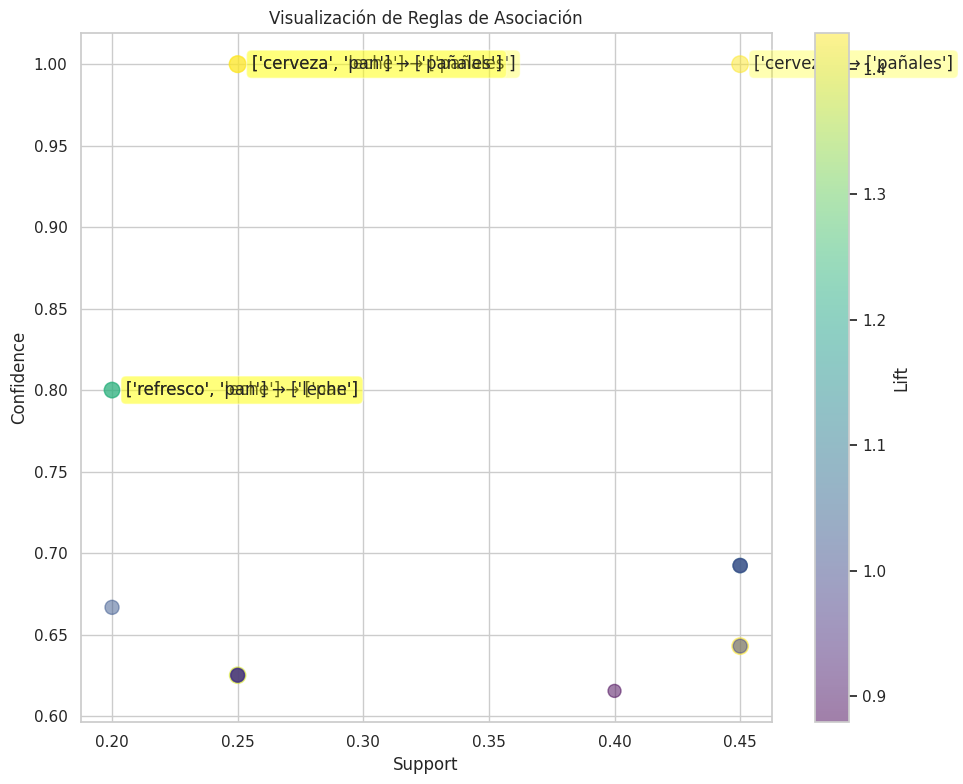

In [7]:
plt.figure(figsize=(10, 8))
plt.scatter(rules['support'], rules['confidence'], alpha=0.5, s=rules['lift']*100, c=rules['lift'], cmap='viridis')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Visualización de Reglas de Asociación')

for i in range(min(5, len(rules))):
    plt.annotate(f"{list(rules.iloc[i]['antecedents'])} → {list(rules.iloc[i]['consequents'])}",
                 xy=(rules.iloc[i]['support'], rules.iloc[i]['confidence']),
                 xytext=(10, 0), textcoords='offset points',
                 horizontalalignment='left', verticalalignment='center',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

8. Visualización reglas más interesantes

In [8]:
print("\nAnálisis de las 3 reglas con mayor lift:")
for i in range(min(3, len(rules))):
    rule = rules.iloc[i]
    antecedents = list(rule['antecedents'])
    consequents = list(rule['consequents'])
    print(f"Regla {i+1}: Si un cliente compra {', '.join(antecedents)}, entonces hay una probabilidad del {rule['confidence']:.2%} de que también compre {', '.join(consequents)}.")
    print(f"   - Support: {rule['support']:.2f} (frecuencia de ocurrencia)")
    print(f"   - Confidence: {rule['confidence']:.2f} (probabilidad condicional)")
    print(f"   - Lift: {rule['lift']:.2f} (cuántas veces más probable es esta relación vs. ocurrencia aleatoria)")
    print("   - Interpretación: " + ("Esta es una regla fuerte y significativa." if rule['lift'] > 2 else "Esta regla muestra cierta correlación."))
    print()


Análisis de las 3 reglas con mayor lift:
Regla 1: Si un cliente compra cerveza, entonces hay una probabilidad del 100.00% de que también compre pañales.
   - Support: 0.45 (frecuencia de ocurrencia)
   - Confidence: 1.00 (probabilidad condicional)
   - Lift: 1.43 (cuántas veces más probable es esta relación vs. ocurrencia aleatoria)
   - Interpretación: Esta regla muestra cierta correlación.

Regla 2: Si un cliente compra cerveza, leche, entonces hay una probabilidad del 100.00% de que también compre pañales.
   - Support: 0.25 (frecuencia de ocurrencia)
   - Confidence: 1.00 (probabilidad condicional)
   - Lift: 1.43 (cuántas veces más probable es esta relación vs. ocurrencia aleatoria)
   - Interpretación: Esta regla muestra cierta correlación.

Regla 3: Si un cliente compra cerveza, pan, entonces hay una probabilidad del 100.00% de que también compre pañales.
   - Support: 0.25 (frecuencia de ocurrencia)
   - Confidence: 1.00 (probabilidad condicional)
   - Lift: 1.43 (cuántas vece

## Actividad: Aplique los mismos pasos al dataset Groceries de Kaggle
1. Navegue a https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset/data
2. Revise la página y entienda los datos.
3. Carque los datos e imprima las primeras columnas

In [15]:
import pandas as pd

try:
    groceries_df = pd.read_csv('Groceries_dataset.csv')
    print("Primeras 5 filas del dataset Groceries:")
    print(groceries_df.head())
except FileNotFoundError:
    print("Error: 'Groceries_dataset.csv' no encontrado. Por favor, asegúrate de que el archivo esté en el entorno de Colab.")
    print("Puedes descargarlo de la página de Kaggle (https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset/data) y luego subirlo a Colab o montarlo desde Google Drive.")

Primeras 5 filas del dataset Groceries:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


4. Imprima información de variables del dataframe, revise si hay valores nulos

In [16]:
print("Información general del DataFrame groceries_df:")
groceries_df.info()

Información general del DataFrame groceries_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [17]:
print("\nValores nulos por columna en groceries_df:")
print(groceries_df.isnull().sum())


Valores nulos por columna en groceries_df:
Member_number      0
Date               0
itemDescription    0
dtype: int64


5. Revise la cantidad de productos únicos. Y encuentre la frecuencia de ocurrencia

In [18]:
print("Número de productos únicos:", groceries_df['itemDescription'].nunique())


Número de productos únicos: 167


In [19]:
print("\nFrecuencia de ocurrencia de cada producto (top 20):")
print(groceries_df['itemDescription'].value_counts().head(20))


Frecuencia de ocurrencia de cada producto (top 20):
itemDescription
whole milk            2502
other vegetables      1898
rolls/buns            1716
soda                  1514
yogurt                1334
root vegetables       1071
tropical fruit        1032
bottled water          933
sausage                924
citrus fruit           812
pastry                 785
pip fruit              744
shopping bags          731
canned beer            717
bottled beer           687
whipped/sour cream     662
newspapers             596
frankfurter            580
brown bread            571
pork                   566
Name: count, dtype: int64


6. ¿Cómo podemos obtener de este dataset una tabla similar a la que utilizamos previamente? Es decir una tabla en la que aparezcan transacciones únicas y filas de productos correspondientes

In [21]:
groceries_transactions = groceries_df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()

groceries_transactions_list = groceries_transactions['itemDescription'].apply(lambda x: [str(item) for item in x]).tolist()

print("Primeras 5 transacciones (ejemplo):")
for i, transaction in enumerate(groceries_transactions_list[:5]):
    print(f"Transacción {i+1}: {', '.join(transaction)}")

Primeras 5 transacciones (ejemplo):
Transacción 1: sausage, whole milk, semi-finished bread, yogurt
Transacción 2: whole milk, pastry, salty snack
Transacción 3: canned beer, misc. beverages
Transacción 4: sausage, hygiene articles
Transacción 5: soda, pickled vegetables


7. ¿Cuál es la cantidad de transacciones resultantes?

In [22]:
print("Cantidad total de transacciones:", len(groceries_transactions_list))

Cantidad total de transacciones: 14963


8. Siga los mismos pasos previos para encontrar Reglas de Asociación utilizando Apriori. Y revisar las más importantes

In [23]:
te_groceries = TransactionEncoder()
te_ary_groceries = te_groceries.fit_transform(groceries_transactions_list)
df_groceries = pd.DataFrame(te_ary_groceries, columns=te_groceries.columns_)

print("Primeras filas del dataset de Groceries transformado (one-hot encoded):")
print(df_groceries.head())

Primeras filas del dataset de Groceries transformado (one-hot encoded):
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vine

In [31]:
frequent_itemsets_groceries = apriori(df_groceries, min_support=0.001, use_colnames=True)
print("\nItemsets frecuentes encontrados en el dataset de Groceries (top 10 por support, con min_support=0.001):\n")
print(frequent_itemsets_groceries.sort_values('support', ascending=False).head(10))
print(frequent_itemsets_groceries.info())


Itemsets frecuentes encontrados en el dataset de Groceries (top 10 por support, con min_support=0.001):

      support            itemsets
146  0.157923        (whole milk)
90   0.122101  (other vegetables)
109  0.110005        (rolls/buns)
123  0.097106              (soda)
147  0.085879            (yogurt)
110  0.069572   (root vegetables)
139  0.067767    (tropical fruit)
10   0.060683     (bottled water)
115  0.060349           (sausage)
28   0.053131      (citrus fruit)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   750 non-null    float64
 1   itemsets  750 non-null    object 
dtypes: float64(1), object(1)
memory usage: 11.8+ KB
None


In [28]:
rules_groceries = association_rules(frequent_itemsets_groceries, metric="confidence", min_threshold=0.2)
print("\nReglas de asociación generadas para Groceries (top 10 por confianza y lift, con min_threshold=0.2):\n")
rules_groceries = rules_groceries.sort_values(['confidence', 'lift'], ascending=[False, False])
print(rules_groceries[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Reglas de asociación generadas para Groceries (top 10 por confianza y lift, con min_threshold=0.2):

             antecedents   consequents   support  confidence      lift
1      (yogurt, sausage)  (whole milk)  0.001470    0.255814  1.619866
0  (rolls/buns, sausage)  (whole milk)  0.001136    0.212500  1.345594


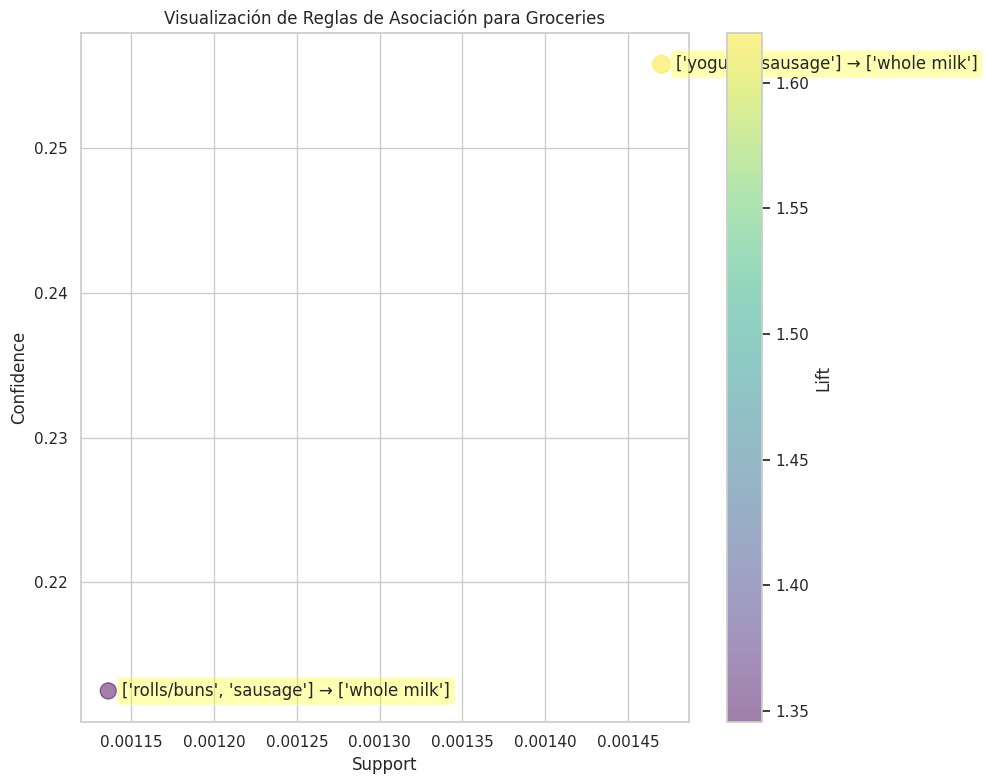

In [30]:
plt.figure(figsize=(10, 8))
plt.scatter(rules_groceries['support'], rules_groceries['confidence'], alpha=0.5, s=rules_groceries['lift']*100, c=rules_groceries['lift'], cmap='viridis')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Visualización de Reglas de Asociación para Groceries')

for i in range(min(5, len(rules_groceries))):
    plt.annotate(f"{list(rules_groceries.iloc[i]['antecedents'])} → {list(rules_groceries.iloc[i]['consequents'])}",
                 xy=(rules_groceries.iloc[i]['support'], rules_groceries.iloc[i]['confidence']),
                 xytext=(10, 0), textcoords='offset points',
                 horizontalalignment='left', verticalalignment='center',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

plt.tight_layout()
plt.show()